# Understanding EXAFS analysis, step by step

`01_quickstart.ipynb` calls a few high-level functions (`pre_edge`, `autobk`,
`ft_windowed`) that each do several things internally. This notebook opens
those up: we rebuild the pipeline by hand, one physical idea at a time, using
the low-level pieces of `escape.exafs` (and a bit of plain numpy/scipy) so
you can see exactly what's happening at each stage.

We'll use the same real Cu foil data as the quickstart notebook.


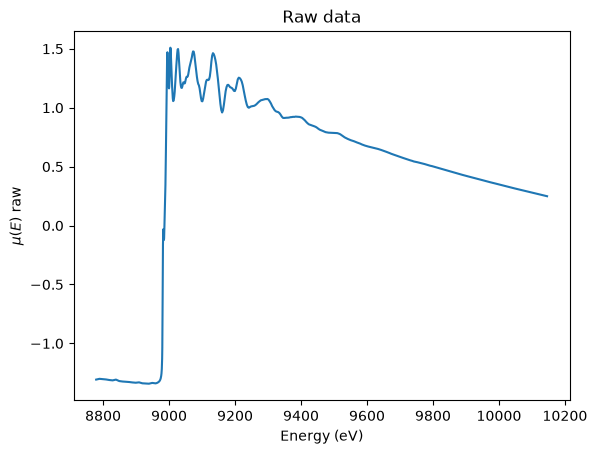

In [1]:
import os
import escape.exafs, os  # data path resolved from the installed package

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LSQUnivariateSpline

from escape import exafs as ex
from escape.exafs.constants import ETOK

energy, mu = ex.read_columns(os.path.join(os.path.dirname(escape.exafs.__file__), "data", "cu_rt01.xmu"))
plt.plot(energy, mu)
plt.xlabel("Energy (eV)"); plt.ylabel(r"$\mu(E)$ raw")
plt.title("Raw data")
plt.show()


## Step 1 — Find E0

E0 is conventionally taken as the inflection point of the rising edge, i.e.
the energy where `dmu/dE` is largest. `find_e0` just computes a numerical
derivative with `numpy.gradient` and finds its maximum (restricted to the
central part of the scan so edge effects at the very start/end of the data
don't get picked up by mistake).


E0 (naive argmax)   : 8980.5
E0 (find_e0 helper)  : 8980.5


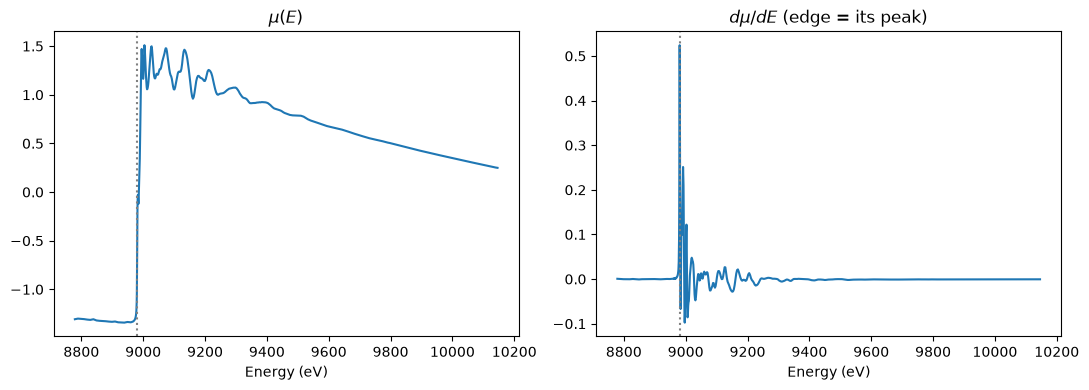

In [2]:
deriv = np.gradient(mu, energy)

e0_manual = energy[np.argmax(deriv)]
e0_helper = ex.find_e0(energy, mu)
print("E0 (naive argmax)   :", e0_manual)
print("E0 (find_e0 helper)  :", e0_helper)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(energy, mu); axes[0].axvline(e0_helper, color="gray", ls=":")
axes[0].set_title(r"$\mu(E)$"); axes[0].set_xlabel("Energy (eV)")
axes[1].plot(energy, deriv); axes[1].axvline(e0_helper, color="gray", ls=":")
axes[1].set_title(r"$d\mu/dE$ (edge = its peak)"); axes[1].set_xlabel("Energy (eV)")
plt.tight_layout(); plt.show()


## Step 2 — Pre-edge line and post-edge normalization, by hand

We fit:
- a **straight line** through the pre-edge region (well below E0), and
- a **2nd-order polynomial** through the post-edge region (well above E0),

then define the **edge step** as the *difference between the two fitted
curves, evaluated at E0* — i.e. "how big was the jump, extrapolated to
exactly E0". Dividing by it puts mu(E) on a scale that runs from ~0 (below
the edge) to ~1 (normalized absorption).


E0 = 8980.50 eV,  edge step = 2.8255


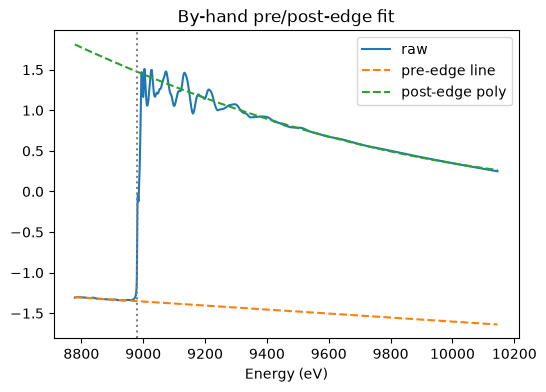

library edge_step: 2.825489184762714  (should match the by-hand value above)


In [3]:
e0 = e0_helper

pre_mask  = (energy >= e0 - 150) & (energy <= e0 - 30)
post_mask = (energy >= e0 + 150)

pre_line  = np.poly1d(np.polyfit(energy[pre_mask],  mu[pre_mask],  1))
post_poly = np.poly1d(np.polyfit(energy[post_mask], mu[post_mask], 2))

edge_step = post_poly(e0) - pre_line(e0)
norm = (mu - pre_line(energy)) / edge_step
print(f"E0 = {e0:.2f} eV,  edge step = {edge_step:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(energy, mu, label="raw")
ax.plot(energy, pre_line(energy), "--", label="pre-edge line")
ax.plot(energy, post_poly(energy), "--", label="post-edge poly")
ax.axvline(e0, color="gray", ls=":")
ax.legend(); ax.set_xlabel("Energy (eV)"); ax.set_title("By-hand pre/post-edge fit")
plt.show()

# sanity check against the library function:
pre_lib = ex.pre_edge(energy, mu)
print("library edge_step:", pre_lib.edge_step, " (should match the by-hand value above)")


## Step 3 — Energy to k: the "q conversion"

Above E0, the ejected photoelectron behaves (to a good first approximation)
like a free particle with kinetic energy `E - E0`. Its de Broglie wavenumber
is

```
k = sqrt( 2 m_e (E - E0) / hbar^2 ) = sqrt( ETOK * (E - E0) )
```

with `ETOK = 2 m_e / hbar^2 = 0.2624682917 eV^-1 Ang^-2` when E is in eV and
k comes out in inverse Angstroms. This *same* quantity is sometimes called
`q` in older papers — `escape.exafs.energy_to_q` is provided as a literal
alias of `energy_to_k` for that reason, they compute the identical number.


max |k_manual - k_helper| = 0.0
max |k_helper - k_alias|  = 0.0


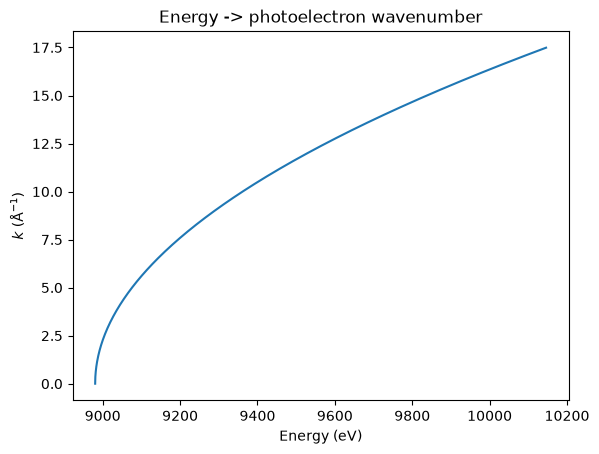

In [4]:
mask = energy >= e0
e_above = energy[mask]
mu_above = mu[mask]

k_manual = np.sqrt(ETOK * (e_above - e0))
k_helper = ex.energy_to_k(e_above, e0)
k_alias  = ex.energy_to_q(e_above, e0)   # identical function, "q" name

print("max |k_manual - k_helper| =", np.max(np.abs(k_manual - k_helper)))
print("max |k_helper - k_alias|  =", np.max(np.abs(k_helper - k_alias)))

plt.plot(e_above, k_helper)
plt.xlabel("Energy (eV)"); plt.ylabel(r"$k$ ($\mathrm{\AA}^{-1}$)")
plt.title("Energy -> photoelectron wavenumber")
plt.show()


## Step 4 — Background removal: why a *spline* and why `rbkg`?

mu0(k) (the hypothetical "no neighbors" background) has to be inferred from
the data, since we can't measure it directly. The trick used by AUTOBK-style
algorithms (and by `escape.exafs.background.autobk`):

- A cubic spline with knots spaced `Delta_k = pi / (2 * rbkg)` apart is, by
  construction, too "stiff" (too low a maximum spatial frequency) to
  reproduce an EXAFS wiggle coming from a shell farther away than `rbkg`.
- So if we fit *only* such a spline through the post-edge mu(k) data, the
  fit is physically forced to capture just the slow background trend and
  leave real EXAFS wiggles (from shells beyond `rbkg`) as residual.
- `autobk` additionally *refines* the spline knot heights by directly
  minimizing the low-R content of chi(R) (the full AUTOBK idea) rather than
  just doing a plain least-squares spline fit.

Let's do the simple (non-refined) version by hand first, then compare to the
full refined result from the library.


rbkg=1.0 Ang  ->  knot spacing=1.57 1/Ang  ->  13 knots


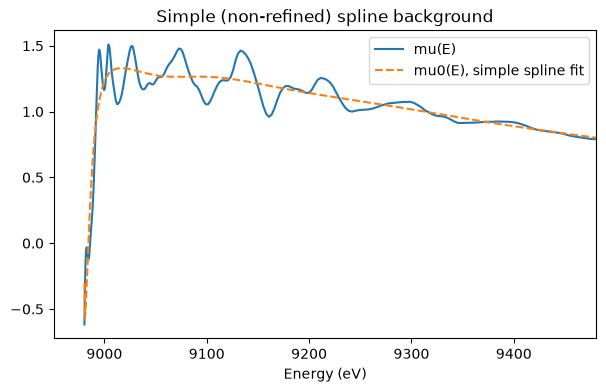

In [5]:
rbkg = 1.0
kmin, kmax = 0.0, k_helper.max()

spacing = np.pi / (2 * rbkg)
n_knots = int(np.ceil((kmax - kmin) / spacing)) + 1
knots = np.linspace(kmin, kmax, n_knots)
print(f"rbkg={rbkg} Ang  ->  knot spacing={spacing:.2f} 1/Ang  ->  {n_knots} knots")

spline = LSQUnivariateSpline(k_helper, mu_above, knots[1:-1], k=3)
mu0_simple = spline(k_helper)
chi_simple = (mu_above - mu0_simple) / edge_step

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e_above, mu_above, label="mu(E)")
ax.plot(e_above, mu0_simple, "--", label="mu0(E), simple spline fit")
ax.plot(e_above, mu0_simple, "o", ms=0, color="none")  # keep autoscale nice
ax.set_xlim(e0 - 30, e0 + 500)
ax.legend(); ax.set_xlabel("Energy (eV)")
ax.set_title("Simple (non-refined) spline background")
plt.show()


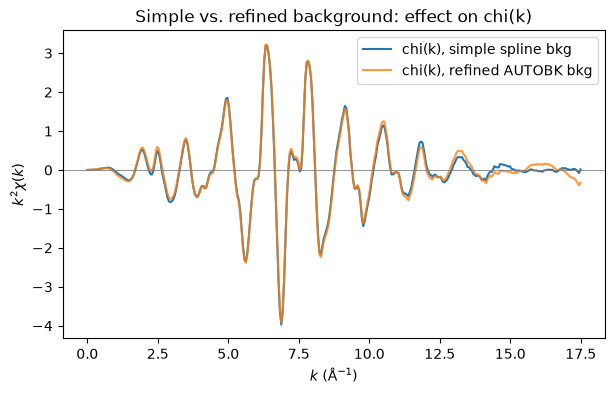

In [6]:
# Now compare to the library's refined AUTOBK, which additionally minimizes
# the low-R content of chi(R) rather than just least-squares fitting mu(E):
bkg = ex.autobk(energy, mu, e0, edge_step, rbkg=rbkg, refine=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_helper, ex.kweight_chi(k_helper, chi_simple, 2), label="chi(k), simple spline bkg")
ax.plot(bkg.k, ex.kweight_chi(bkg.k, bkg.chi, 2), label="chi(k), refined AUTOBK bkg", alpha=0.8)
ax.axhline(0, color="gray", lw=0.6)
ax.legend(); ax.set_xlabel(r"$k$ ($\mathrm{\AA}^{-1}$)"); ax.set_ylabel(r"$k^2\chi(k)$")
ax.set_title("Simple vs. refined background: effect on chi(k)")
plt.show()


Notice the refined background gives a visibly *flatter, more even*
`k^2*chi(k)` across the whole range — the simple least-squares spline tends
to "chase" some of the real oscillation at low k, damping the signal there,
which the R-space refinement corrects for.

## Step 5 — Windowing and the Fourier transform, by hand

We resample chi(k) onto a uniform k-grid (real data is uniform in *energy*,
not k), multiply by `k^kweight` and a taper window, and FFT. The window
matters: an abrupt cutoff at kmin/kmax acts like multiplying by a box
function, which produces "sinc" ripples in R-space; a smooth taper (Hanning,
here) avoids that.


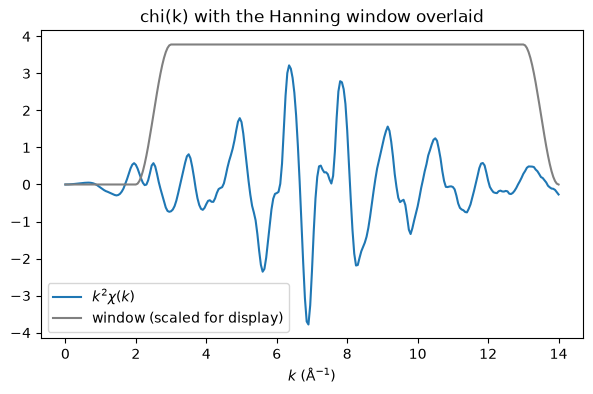

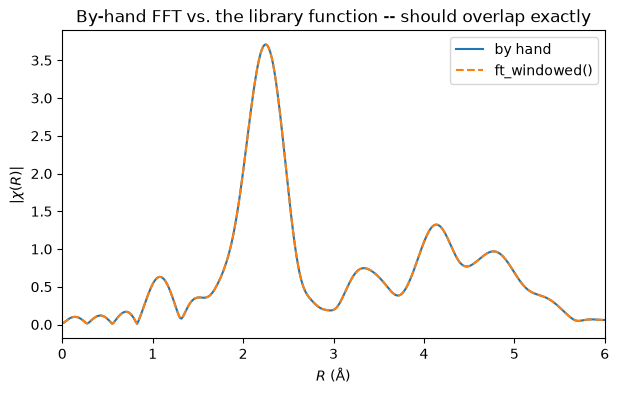

In [7]:
kmin_ft, kmax_ft, dk_taper, kweight = 3.0, 13.0, 1.0, 2
kstep = 0.05

kuniform = np.arange(0, kmax_ft + dk_taper + kstep, kstep)
chi_uniform = np.interp(kuniform, bkg.k, bkg.chi, left=0.0, right=0.0)

win = ex.window(kuniform, kmin_ft, kmax_ft, dk=dk_taper, kind="hanning")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kuniform, ex.kweight_chi(kuniform, chi_uniform, kweight), label=r"$k^2\chi(k)$")
ax.plot(kuniform, win * np.nanmax(np.abs(ex.kweight_chi(kuniform, chi_uniform, kweight))),
        label="window (scaled for display)", color="gray")
ax.legend(); ax.set_xlabel(r"$k$ ($\mathrm{\AA}^{-1}$)")
ax.set_title("chi(k) with the Hanning window overlaid")
plt.show()

weighted = chi_uniform * (kuniform ** kweight) * win
n = 2048
M = 2 * n
fft_vals = np.fft.fft(weighted, n=M) * kstep
r_manual = np.pi * np.arange(n) / (M * kstep)
chir_manual = fft_vals[:n] / np.sqrt(np.pi)

# compare to the library function
r_lib, chir_lib, _ = ex.ft_windowed(bkg.k, bkg.chi, kweight=kweight, window="hanning",
                                     kmin=kmin_ft, kmax=kmax_ft, dk=dk_taper)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_manual, np.abs(chir_manual), label="by hand")
ax.plot(r_lib, np.abs(chir_lib), "--", label="ft_windowed()")
ax.set_xlim(0, 6); ax.legend()
ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)"); ax.set_ylabel(r"$|\chi(R)|$")
ax.set_title("By-hand FFT vs. the library function -- should overlap exactly")
plt.show()


## Recap

| Physical question | Function | Key idea |
|---|---|---|
| Where's the edge? | `find_e0` | peak of dmu/dE |
| What's the real EXAFS amplitude scale? | `pre_edge` | pre-edge line + post-edge poly -> edge step |
| What's the photoelectron doing? | `energy_to_k` (= `energy_to_q`) | free-electron dispersion, `k = sqrt(ETOK*(E-E0))` |
| What's the smooth "no neighbors" background? | `autobk` | spline stiffness tied to `rbkg`, refined against low-R chi(R) |
| Where are the neighboring shells? | `ft_windowed` | k-weighted, windowed Fourier transform |

From here, the natural next step (not covered by this package) is fitting
`chi(k)`/`chi(R)` against theoretical scattering paths (e.g. FEFF) to get
quantitative bond distances, coordination numbers, and disorder parameters.
